In [1]:
import numpy as np
import matplotlib.pyplot as plt
import uproot as up

In [2]:
isSafeFiles=False

In [3]:
def Plot1D_KDE(valO,ValG4,FileName,Title,Binsize=200,labelx="x",isPlottext=False,isHistType="numpy",opacity=1,fontsize=30,width=5,lbls=["Geant4","Opticks"],tp="diff"):
    maXX = np.max(np.array([np.max(ValG4),np.max(valO)]))
    miNX = np.min(np.array([np.min(ValG4),np.min(valO)]))
    lins1X = np.linspace(miNX,maXX,Binsize)
    fig, ax = plt.subplots(2, 1, figsize=(25, 15), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    x = 0
    y = 0
    if(isPlottext):
        if(isHistType=="numpy"):
            x = np.histogram(ValG4, bins=lins1X)
        else:
            x = plt.hist(ValG4, bins=lins1X)
        h1=ax[0].hist(ValG4,color="red",label=lbls[0],bins=lins1X,histtype="step",fill=False,linestyle="-",linewidth=width,alpha=opacity);
    else:
        #sns.histplot(data=G4Dict,x=lbl,color="orange",label="Geant4",bins=Binsz,kde=False,element="step",fill=False,linestyle="-",linewidth=width,alpha=opacity);
        h1=ax[0].hist(ValG4,color="red",label=lbls[0],bins=lins1X,histtype="step",fill=False,linestyle="-",linewidth=width,alpha=opacity);
    
    x=0
    y=0
    fitx=0
    fity=0
    
    if(isPlottext):
        binX = np.linspace(np.min(valO[0]) , np.max(valO[0]) , Binsize)
        if(isHistType=="numpy"):
            x = np.histogram(valO[0], bins=binX)
        else:
            x = np.histogram(valO[0], bins=binX)
        h2=ax[0].hist(valO,color="green",label=lbls[1],bins=lins1X,histtype="step",fill=False,linestyle="--",linewidth=width,alpha=opacity);
    else:    
        #sns.histplot(data=OpticksDict,x=lbl,color="blue",label="Opticks",bins=Binsz,kde=False,element="step",fill=False,linestyle="--",linewidth=width,alpha=opacity)
        h2=ax[0].hist(valO,color="green",label=lbls[1],bins=lins1X,histtype="step",fill=False,linestyle="--",linewidth=width,alpha=opacity);

    #Ratio Plot    
    # Calculate histogram counts for ratio plot - MUST use same bins
    counts1,bin_edges,_ = h1
    counts2,_,_ = h2 # Use the same bin_edges

    # Calculate bin centers for plotting the ratio
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    numerator_val = 0
    combinedarray = 0
    denominator_val = 0
    result=[]
    res_err=[]
    label=""
    ylabel=""
    xlabel=""
   
    
    if(tp == "diff"):
        label="Difference"
        ylabel="diff / max"
        xlabel=labelx
        numerator_val = counts2 - counts1
        combinedarray = np.concatenate((counts1, counts2))
        denominator_val = 1#np.max(combinedarray)
        
        eps = 1e-12
        numerator_val = np.where(np.abs(numerator_val) < eps, eps, numerator_val)
        denominator_val = np.where(np.abs(denominator_val) < eps, eps, denominator_val)
        result  = numerator_val / denominator_val
        error_numerator = np.sqrt(counts1 + counts2)
        error_denominator = np.sqrt(counts1) # <-- The error from the value you divide by
        res_err = np.abs(result) * np.sqrt((error_numerator / numerator_val)**2 +(error_denominator / denominator_val)**2)        
    elif( tp == "ratio"):
        label="Ratio G4/Opticks"
        ylabel="Ratio"
        xlabel=labelx
        # Poisson errors (or replace with your own errors)
        err1 = np.sqrt(counts1)
        err2 = np.sqrt(counts2)

        # ratio
        result  = counts2 / counts1
        # propagated error
        res_err = result * np.sqrt((err2 / counts2)**2 + (err1 / counts1)**2)
    if(len(result)<1):
        print (f"Check type {tp}, vector does not have any element")
        return
 
    #error_numerator = np.sqrt(counts1 + counts2)
    #error_denominator = np.sqrt(counts1) # <-- The error from the value you divide by
    
  

    # Use scientific notation for the axis 
    ax[0].ticklabel_format(axis='y', style='sci', scilimits=(4,4))
    ax[0].tick_params(axis='both',which="major",labelsize=fontsize+10)
    ax[1].tick_params(axis='both',which="major",labelsize=fontsize+10)


    ax[0].set_ylabel("Frequency",fontsize=fontsize+10)
    #ax[0].set_xlabel(lbl,fontsize=fontsize+10)
    ax[0].yaxis.get_offset_text().set_size(fontsize+10) # Adjust the font size here
    ax[0].legend(fontsize=fontsize)   
    ax[0].set_title(Title,fontweight="bold",ha="center",fontsize=fontsize+20)
    ax[0].semilogy()
    
    if (isSafeFiles):
        plt.savefig(f"{SavePath}/{FileName[0]}.png")
    
    print (f" Size Bin_Centers is {len(bin_centers)}")
    print (f" Size result {len(result)} min, max {np.max(result)} , {np.min(result)}")    
    print (f" Size res_err {len(res_err)} min, max {np.max(res_err)} , {np.min(res_err)}")    
    
    #ax[1].plot(bin_centers, ratio, marker='o', linestyle='-', color='black', markersize=5)
    ax[1].errorbar(bin_centers, result, yerr=res_err, fmt='o', color='black',
                    markersize=5, capsize=3, elinewidth=1, label=label) # fmt='o' for points
    ax[1].axhline(1, color='grey', linestyle='--', linewidth=1)
    ax[1].set_xlabel(xlabel,fontsize=fontsize+10)
    ax[1].set_ylabel(ylabel,fontsize=(fontsize+10))
    ax[1].grid(True, linestyle=':', alpha=0.6)
    #ax[1].set_ylim(-np.max(res_err),np.max(res_err))
    #print(f"result {result}")
    #print(f"res_err {res_err}")
    #ax[1].semilogy()
    #ax[1].ticklabel_format(axis='y', style='sci', scilimits=(0.01,0.01))
    ax[1].tick_params(axis='both',which="major",labelsize=fontsize+10)
        
    
def FitHist1D(hist,ax,label,clr,ap,width=3,linstyle="-"):
    ## Locate Min and Max
    MinAndMaxMask=(hist[0]>=(np.mean(hist[0])*0.1)) & (hist[0]<=np.max(hist[0])*0.9)
    
    initials=(np.max(hist[0]),np.mean(hist[1][:-1][MinAndMaxMask]),np.std(hist[1][:-1][MinAndMaxMask]),0,0)
    #initials=(np.max(hist[0]),0,np.std(hist[1][:-1][MinAndMaxMask]),0,0)
    print(f"Initials {initials}")
    fit=scp.curve_fit(Gauss1DSkew,hist[1][:-1],hist[0],p0=initials,maxfev=5000)
    String_=label+r'$\bar{X}$'+f"={round(fit[0][1],2)}," + r'$\sigma$' +f"= {abs(round(fit[0][2],2))}"
    #ax.text(np.min(data),fit[0][0],s=String_,color=clr)
    if(ax):
        ax.plot(hist[1][:-1],Gauss1DSkew(hist[1][:-1],*fit[0]),label=String_,color=clr,linestyle=linstyle,alpha=ap,linewidth=width)
    FitValues={"Amp":round(fit[0][0],2),"u":round(fit[0][1],2),"sigma":abs(round(fit[0][2],2)),"offset":round(fit[0][3],2)}
    print(FitValues)
    return FitValues    

In [4]:
PSpOpticks=up.open("../Performance_Opticks_Sphoton.root")
PG4=up.open("../Performance_Study/Performance_G4.root")
#PG4=up.open("../MTPerformance_G4_full_nowires.root")
PG4MT=up.open("../Performance_Study/MTPerformance_G4.root")
#PG4MT=up.open("../MTPerformance_G4.root")
AlphaTest=up.open("../AlphaTest.root")

In [5]:
POpticks=up.open("../Performance_Study/Performance_Opticks.root")


In [6]:
print (PG4.keys())

['generator;1', 'OpticksHits;1', 'Geant4Hits;1', 'PhotonInfo;1']


In [7]:
PG4["PhotonInfo"]

<TTree 'PhotonInfo' (7 branches) at 0x7f12995bae40>

In [8]:
POTime=POpticks["PhotonInfo/Time"].array().to_numpy()
POPhotons=POpticks["PhotonInfo/OScintPhotons"].array().to_numpy()/1e6


In [9]:
PSG4Time=PG4["PhotonInfo/Time"].array().to_numpy()
PSG4Photons=PG4["PhotonInfo/G4ScintPhotons"].array().to_numpy()/1e6
print(PSG4Time)

[  3.07206206  13.67482848  23.67034474  33.76990831  44.15878897
  54.27182983  64.35068274  75.08678773  85.01942934  95.77201621
 105.92615443 116.71436922 126.54471825 137.03227278 147.27442606
 149.54594473 159.21860869 171.12618079 178.8120891  189.92568078
 199.8366692  209.40939685 219.27604696 227.79558307 237.61756478
 247.42450375 258.41634707 267.76870751 276.40160064 288.77912109]


In [10]:
PG4MT_Time=PG4MT["PhotonInfo/Time"].array().to_numpy()
PG4MT_Photons=PG4MT["PhotonInfo/G4ScintPhotons"].array().to_numpy()/1e6
PG4MT_BatchID=PG4MT["PhotonInfo/BatchID"].array().to_numpy()
UniqueBatchID=np.unique_counts(PG4MT_BatchID)

In [11]:
Photons=np.array([])
AvgTime=np.array([])
StdTime=np.array([])
rep=1
for i in UniqueBatchID[0]:
    BatchMask=PG4MT_BatchID==i
    Photons=np.append(Photons,np.sum(PG4MT_Photons[BatchMask])/rep) # 2 comes from the amount of repitation 
    AvgTime=np.append(AvgTime,np.mean(PG4MT_Time[BatchMask]))
    StdTime=np.append(StdTime,np.std(PG4MT_Time[BatchMask]))

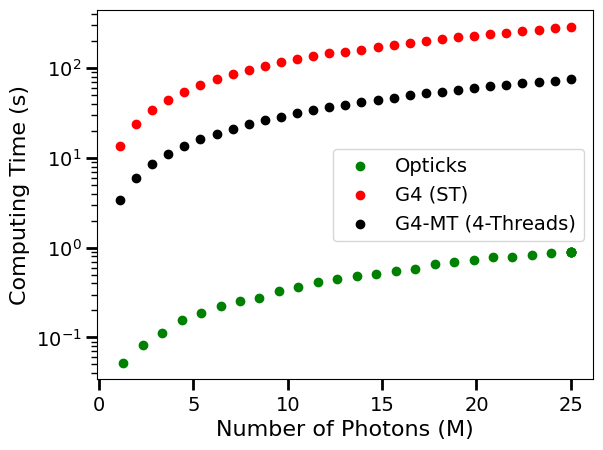

In [12]:


plt.scatter(POPhotons[1:], POTime[1:], marker="o", label="Opticks", color="green")
plt.scatter(PSG4Photons[1:], PSG4Time[1:], marker="o", label="G4 (ST)", color="red")
plt.scatter(Photons[1:], AvgTime[1:], marker="o", label="G4-MT (4-Threads)", color="black")

plt.semilogy()
plt.xlabel("Number of Photons (M)", fontsize="16")
plt.ylabel("Computing Time (s)", fontsize="16")

# --- Make Ticks Larger ---
# labelsize: increases the text size of the numbers
# size: increases the length of the tick dash marks
# width: increases the thickness of the tick dash marks
plt.tick_params(axis='both', which='major', labelsize=14, size=8, width=2)
plt.tick_params(axis='both', which='minor', size=4, width=1) # Adjusts small log ticks

plt.legend(fontsize=14)
plt.show()


In [13]:
from scipy import stats
def GetSlope(x,y):
    # Perform linear regression
    res = stats.linregress(x, y)

    # Extract slope and its standard error
    slope = res.slope
    slope_error = res.stderr
    print(f"Slope: {slope:.4f}")
    print(f"Error on Slope (SE): {slope_error:.4f}")
    print("Photons")
    print(x)
    print("Time")
    print(y)
    return slope, slope_error
def error_prop_ratio(x, x_error, y, y_error):
    """
    Calculates the absolute propagated error for the ratio (x / y).
    Assumes x and y are completely independent.
    """
    ratio = x / y
    error=ratio * np.sqrt((x_error / x)**2 + (y_error / y)**2)
    print(f"Ratio is {round(ratio,2)} and error is {round(error,2)}")
    
    # Multiply the fractional error by the ratio to get absolute error
    return  round(ratio,2),round(error,2)


In [14]:
print(f"MT {AvgTime[1:]/POTime[1:]}")
print(f"G4 {PSG4Time[1:]/POTime[1:]}")

print("------ G4 ------")
G4Slope=GetSlope(PSG4Photons[1:],PSG4Time[1:])
print("------ G4 MT ------")
G4MTlope=GetSlope(Photons[1:],AvgTime[1:])
print("------ Opticks ------")
OSlope=GetSlope(POPhotons[1:],POTime[1:])

MT [64.4264101  71.96651544 74.61005946 70.73744474 72.91833793 71.35574339
 73.64036763 76.4827528  71.38923205 72.36616591 70.18780821 69.29518041
 69.75316254 71.3391691  70.77497831 72.80080316 67.94818737 68.40414376
 68.71839936 66.98707625 69.23091348 69.0641555  68.79468897 70.68641947
 72.86634147 76.03262257 79.39906977 81.90746457 84.71707116]
G4 [261.22076121 288.691043   298.82591366 285.90164264 292.40698401
 285.62592313 297.26262314 307.41643195 288.20107061 292.17909248
 284.50475573 279.47526408 282.12463595 288.89926293 271.99375296
 277.2052056  262.85536062 260.71597325 262.24063226 255.65607518
 266.18999193 264.44541605 260.37318159 268.6090297  278.3903185
 290.88902879 302.15582696 312.41340583 326.45705982]
------ G4 ------
Slope: 11.3335
Error on Slope (SE): 0.0567
Photons
[ 1.103448  1.956896  2.810344  3.663793  4.517241  5.370689  6.224137
  7.077586  7.931034  8.784482  9.637931 10.491379 11.344827 12.198275
 13.051724 13.905172 14.75862  15.612068 16.465

In [15]:
error_prop_ratio(G4Slope[0],G4Slope[1],OSlope[0],OSlope[1])
error_prop_ratio(G4MTlope[0],G4MTlope[1],OSlope[0],OSlope[1])

Ratio is 313.67 and error is 3.11
Ratio is 83.4 and error is 0.72


(np.float64(83.4), np.float64(0.72))

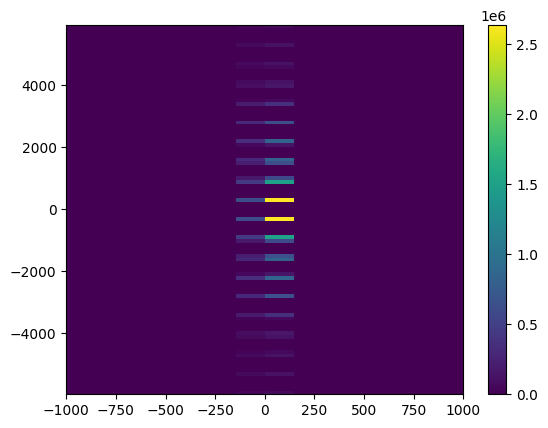

In [16]:
_=plt.hist2d(PG4["Geant4Hits/x"].array().to_numpy(),PG4["Geant4Hits/y"].array().to_numpy(),bins=100)
plt.xlim(-1000,1000)
plt.colorbar()


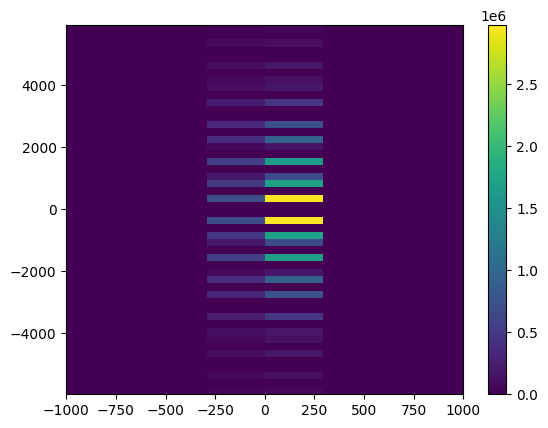

In [17]:
_=plt.hist2d(POpticks["OpticksHits/x"].array().to_numpy(),POpticks["OpticksHits/y"].array().to_numpy(),bins=50)
plt.xlim(-1000,1000)
plt.colorbar()

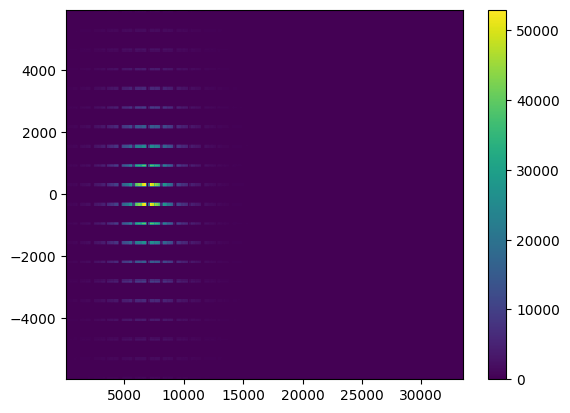

In [18]:
_=plt.hist2d(PG4MT["Geant4Hits/z"].array().to_numpy(),PG4MT["Geant4Hits/y"].array().to_numpy(),bins=300)
plt.colorbar()

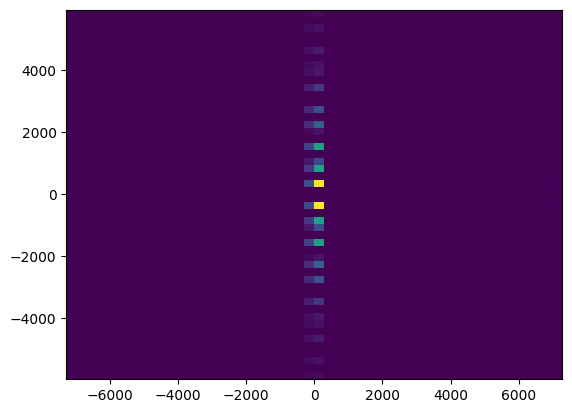

In [19]:
_=plt.hist2d(PG4MT["Geant4Hits/x"].array().to_numpy(),PG4MT["Geant4Hits/y"].array().to_numpy(),bins=50)


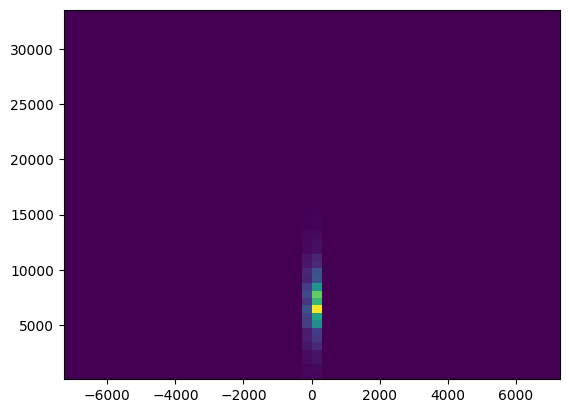

In [20]:
_=plt.hist2d(PG4MT["Geant4Hits/x"].array().to_numpy(),PG4MT["Geant4Hits/z"].array().to_numpy(),bins=50)


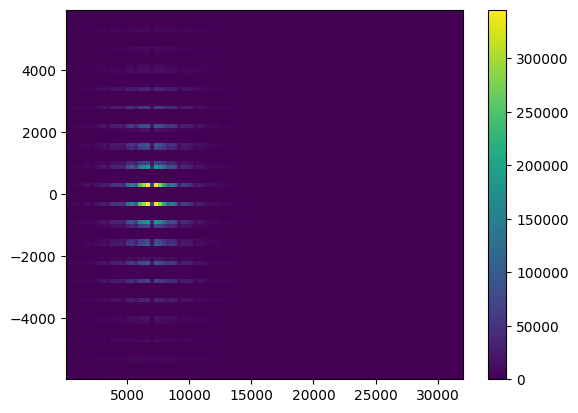

In [21]:
_=plt.hist2d(PG4["Geant4Hits/z"].array().to_numpy(),PG4["Geant4Hits/y"].array().to_numpy(),bins=100)
plt.colorbar()

TypeError: 'FileNotFoundError' object is not subscriptable

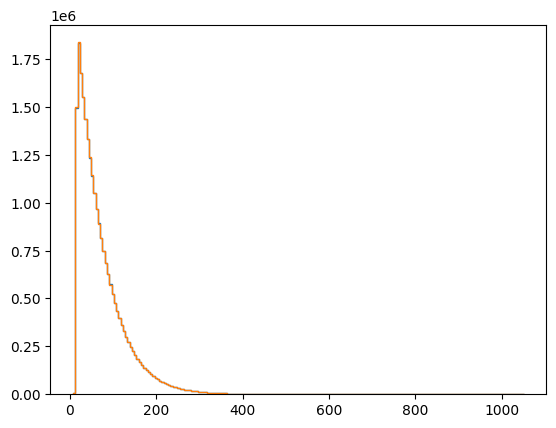

In [22]:
xOSpMask=PSpOpticks["OpticksHits/x"].array().to_numpy()>0
xOMask=POpticks["OpticksHits/x"].array().to_numpy()>0
a = PG4MT["Geant4Hits/t"].array().to_numpy()
b = PG4["Geant4Hits/t"].array().to_numpy()
c = POpticks["OpticksHits/t"].array().to_numpy()
d = PSpOpticks["OpticksHits/t"].array().to_numpy()
xmin = min(a.min(), b.min(),c.min())
xmax = max(a.max(), b.max(),c.max())
xbins = np.linspace(xmin, xmax, 200) 

_=plt.hist(PG4MT["Geant4Hits/t"].array().to_numpy(),bins=xbins,label="G4-MT",histtype="step")
_=plt.hist(PG4["Geant4Hits/t"].array().to_numpy(),bins=xbins,label="G4-ST",histtype="step")
_=plt.hist(POpticks["OpticksHits/t"].array().to_numpy(),bins=xbins,label="Opticks",histtype="step")
#_=plt.hist(PSpOpticks["OpticksHits/t"].array().to_numpy(),bins=xbins,label="Sphoton Opticks",histtype="step")
plt.semilogy()
plt.ylabel("Frequency")
plt.xlabel("Time(ns)")
plt.legend()
plt.show()


In [ ]:
#xOSpMask=PSpOpticks["OpticksHits/x"].array().to_numpy()>0
#xOMask=POpticks["OpticksHits/x"].array().to_numpy()>0
a = PG4MT["Geant4Hits/t"].array().to_numpy()
b = PG4["Geant4Hits/t"].array().to_numpy()
c = POpticks["OpticksHits/t"].array().to_numpy()#[xOMask]
#d = PSpOpticks["OpticksHits/t"].array().to_numpy()#[xOSpMask]
xmin = min(a.min(), b.min(),c.min())
xmax = max(a.max(), b.max(),c.max())
xbins = np.linspace(xmin, xmax, 200) 

_=plt.hist(a,bins=xbins,label="G4-MT",histtype="step")
_=plt.hist(b,bins=xbins,label="G4-ST",histtype="step")
_=plt.hist(c,bins=xbins,label="Opticks",histtype="step")
#_=plt.hist(d,bins=xbins,label="Sphoton Opticks",histtype="step")
#plt.semilogy()
plt.ylabel("Frequency")
plt.xlabel("Time(ns)")
plt.legend()
plt.show()


In [ ]:
_=plt.hist2d(POpticks["OpticksHits/z"].array().to_numpy(),POpticks["OpticksHits/y"].array().to_numpy(),bins=100)


In [ ]:
PG4MT["Geant4Hits/z"].array().to_numpy().max()

In [ ]:
len(POpticks["OpticksHits/x"].array().to_numpy())/len(PG4["Geant4Hits/x"].array().to_numpy())


In [ ]:

a = PG4MT["Geant4Hits/wavelength"].array().to_numpy()
b = PG4["Geant4Hits/wavelength"].array().to_numpy()
c = POpticks["OpticksHits/wavelength"].array().to_numpy()
d = PSpOpticks["OpticksHits/wavelength"].array().to_numpy()[xOSpMask]
xmin = min(a.min(), b.min(), c.min(),d.min())
xmax = max(a.max(), b.max(), c.max(),d.max())
xbins = np.linspace(xmin, xmax, 300) 

_=plt.hist(PG4MT["Geant4Hits/wavelength"].array().to_numpy(),bins=xbins,label="G4-MT",histtype="step")
_=plt.hist(PG4["Geant4Hits/wavelength"].array().to_numpy(),bins=xbins,label="G4-ST",histtype="step")
_=plt.hist(POpticks["OpticksHits/wavelength"].array().to_numpy(),bins=xbins,label="Opticks",histtype="step")
#_=plt.hist(PSpOpticks["OpticksHits/wavelength"].array().to_numpy()[xOSpMask],bins=xbins,label="Spoton Opticks",histtype="step")

plt.ylabel("Frequency")
plt.xlabel("Wavelength (nm)")
plt.semilogy()
plt.legend()
plt.show()


In [ ]:
PSpOpticks["OpticksHits/wavelength"].array().to_numpy()[xOSpMask].size


In [ ]:
(1-b.size/PSpOpticks["OpticksHits/wavelength"].array().to_numpy()[xOSpMask].size)*100

In [ ]:
(1-b.size/POpticks["OpticksHits/wavelength"].array().to_numpy()[xOMask].size)*100

In [ ]:
PG4PropT=PG4["Geant4Hits/t"].array().to_numpy()
POPropT=POpticks["OpticksHits/t"].array().to_numpy()
_=Plot1D_KDE(POPropT,PG4PropT,"Transport Time","Transport Time",Binsize=300,labelx="Time (ns)",isPlottext=False,isHistType="",opacity=0.5,fontsize=30,width=5,lbls=["Geant4","Opticks"],tp="ratio")

In [ ]:
#PG4Wave=PSpOpticks["OpticksHits/wavelength"].array().to_numpy()
PG4Wave=PG4["Geant4Hits/wavelength"].array().to_numpy()
#POpWave=PSpOpticks["OpticksHits/wavelength"].array().to_numpy()
POpWave=POpticks["OpticksHits/wavelength"].array().to_numpy()
_=Plot1D_KDE(POpWave,PG4Wave,"Wavelength","Wavelength",Binsize=300,labelx="Wavelength (nm)",isPlottext=False,isHistType="",opacity=0.5,fontsize=30,width=5,lbls=["Geant4","Opticks"],tp="ratio")

In [ ]:
POpticks["OpticksHits/boundary"].array().to_numpy()


In [ ]:
_=plt.hist(POpticks["OpticksHits/x"].array().to_numpy(),bins=100,alpha=0.5)
_=plt.hist(PG4["Geant4Hits/x"].array().to_numpy(),bins=100,alpha=0.5)
plt.semilogy()